In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_parquet('part_0010.parquet')

In [3]:
df['date']=pd.to_datetime(df['date'])

In [4]:
df['day_of_week']=df['date'].dt.dayofweek.astype('Int8')

In [5]:
df['month']=df['date'].dt.month.astype('Int8')

In [6]:
df['is_weekend']=df['day_of_week'].isin([56]).astype('Int8')

In [7]:
df

,h3_cell,date,future_accidents,label,accidents_today,speed_limit,road_type,first_road_class,first_road_number,junction_detail,...,second_road_number,pedestrian_crossing,road_surface_conditions,weather_conditions,light_conditions,carriageway_hazards,urban_or_rural_area,day_of_week,month,is_weekend
0,8819590881fffff,2020-01-01,0,0,0,60,6,3,35,0,...,-1,0,2,2,1,0,2,2,1,0
1,8819590881fffff,2020-01-02,0,0,0,60,6,3,35,0,...,-1,0,2,2,1,0,2,3,1,0
2,8819590881fffff,2020-01-03,0,0,0,60,6,3,35,0,...,-1,0,2,2,1,0,2,4,1,0
3,8819590881fffff,2020-01-04,0,0,0,60,6,3,35,0,...,-1,0,2,2,1,0,2,5,1,0
4,8819590881fffff,2020-01-05,0,0,0,60,6,3,35,0,...,-1,0,2,2,1,0,2,6,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9099995,88195aa101fffff,2024-12-20,0,0,0,70,3,1,4,0,...,-1,0,1,1,1,0,2,4,12,0
9099996,88195aa101fffff,2024-12-21,0,0,0,70,3,1,4,0,...,-1,0,1,1,1,0,2,5,12,0
9099997,88195aa101fffff,2024-12-22,0,0,0,70,3,1,4,0,...,-1,0,1,1,1,0,2,6,12,0
9099998,88195aa101fffff,2024-12-23,0,0,0,70,3,1,4,0,...,-1,0,1,1,1,0,2,0,12,0


In [8]:
df=df.sort_values(['h3_cell','date'])

In [9]:
df['acc_last_7']=df.groupby('h3_cell')['accidents_today'].rolling(7,min_periods=1).sum().shift(1).reset_index(level=0,drop=True)

In [10]:
df['acc_last_7']=df.groupby('h3_cell')['accidents_today'].rolling(30,min_periods=1).sum().shift(1).reset_index(level=0,drop=True)

In [11]:
df['acc_last_30']=df.groupby('h3_cell')['accidents_today'].rolling(7,min_periods=1).sum().shift(1).reset_index(level=0,drop=True)

In [12]:
feature_cols=[ 'accidents_today','acc_last_7', 'acc_last_30', 'day_of_week', 'month', 'is_weekend', 'speed_limit', 'road_type', 'junction_control', 'pedestrian_crossing', 'urban_or_rural_area', 'weather_conditions']

In [13]:
import xgboost as xgb
bst=xgb.Booster()
bst.load_model('xgb_hotspot.model')

/var/folders/qt/8w5zy69d4c3_bvqdvxnrx3fw0000gn/T/ipykernel_40759/4018797921.py:3: UserWarning: [13:47:39] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  bst.load_model('xgb_hotspot.model')


In [14]:
data_test=xgb.DMatrix(df[feature_cols],label=df['label'],feature_names=feature_cols)
y_pred=bst.predict(data_test,iteration_range=(0, bst.best_iteration + 1))

In [15]:

from sklearn.metrics import roc_auc_score, average_precision_score
auc=roc_auc_score(df['label'],y_pred)
ap=average_precision_score(df['label'],y_pred)
print(f"AUC:{auc:.4f},AveragePrecision(PR-AUC):{ap:.4f}")

AUC:0.7254,AveragePrecision(PR-AUC):0.0576


In [16]:
test_df=df.copy()
test_df['score']=y_pred

In [17]:
cell_score=test_df.groupby('h3_cell')['score'].mean().reset_index()

In [18]:
cell_future=test_df.groupby('h3_cell')['future_accidents'].mean().reset_index()

In [19]:
threshold=cell_future['future_accidents'].quantile(0.90)

In [20]:
cell_future['label']=(cell_future['future_accidents']>=threshold).astype(int)

In [21]:
eval_df=cell_score.merge(cell_future[['h3_cell', 'label']],on='h3_cell',how='inner')

In [22]:
k=5
k=min(k,len(eval_df))
precision_at_k=eval_df.nlargest(k,'score')['label'].mean()
precision_at_k

1.0

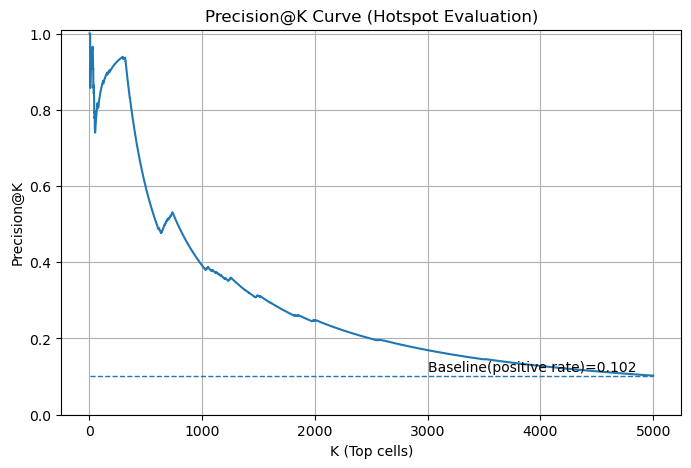

In [27]:
import numpy as np
import matplotlib.pyplot as plt
Ks=np.linspace(1,len(eval_df),len(eval_df),dtype=int)
Ps=[]
for K in Ks:
    K=min(K,len(eval_df))
    p=eval_df.nlargest(K,'score')['label'].mean()
    Ps.append(p)
plt.figure(figsize=(8,5))
plt.plot(Ks,Ps)
plt.ylim(0, 1.01)
plt.xlabel("K (Top cells)")
plt.ylabel("Precision@K")
plt.title("Precision@K Curve (Hotspot Evaluation)")
plt.grid(True)
baseline =eval_df['label'].mean()
plt.hlines(baseline,xmin=Ks.min(),xmax=Ks.max(),linestyles='dashed',linewidth=1)
plt.text(Ks.max()*0.6,baseline+0.01,f'Baseline(positive rate)={baseline:.3f}')

plt.show()


In [49]:
import h3 
import folium as f
from folium.plugins import HeatMap
m=f.Map(location=[51.5072, 0.1276], zoom_start=5)
topK=100


def h3_center(h):
    lat,lng=h3.cell_to_latlng(h)
    return lat,lng

eval_df[['lat', 'lon']]=eval_df['h3_cell'].apply(lambda x:pd.Series(h3_center(x)))
heat_data=eval_df[['lat','lon','score']].values.tolist()

HeatMap(
    heat_data,
    radius=20,
    blur=25,
    max_zoom=13
).add_to(m)


In [50]:
m

In [52]:
import branca.colormap as cm

colormap=cm.linear.YlOrRd_09.scale(eval_df['score'].min(),eval_df['score'].max())

colormap.caption = "Predicted Accident Risk"

In [59]:
m2=f.Map(location=[51.5072, 0.1276], zoom_start=6)
topK=50

top_cells=eval_df.sort_values('score',ascending=False).head(topK)
for _,row in top_cells.iterrows():
    boundary=h3.cell_to_boundary(row['h3_cell'])
    f.Polygon(
            locations=boundary,
                fill_color=colormap(row['score']),
                fill=True,
                fill_opacity=0.7,
                tooltip=row['score']
    ).add_to(m2)
m2